# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadOkasha004/flyrank-ml-internship-work/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

📊 Auditing Distributions for Key Fields: ['sessions_organic', 'gsc_avg_position', 'ctr']



/tmp/ipykernel_4730/747812594.py:51: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


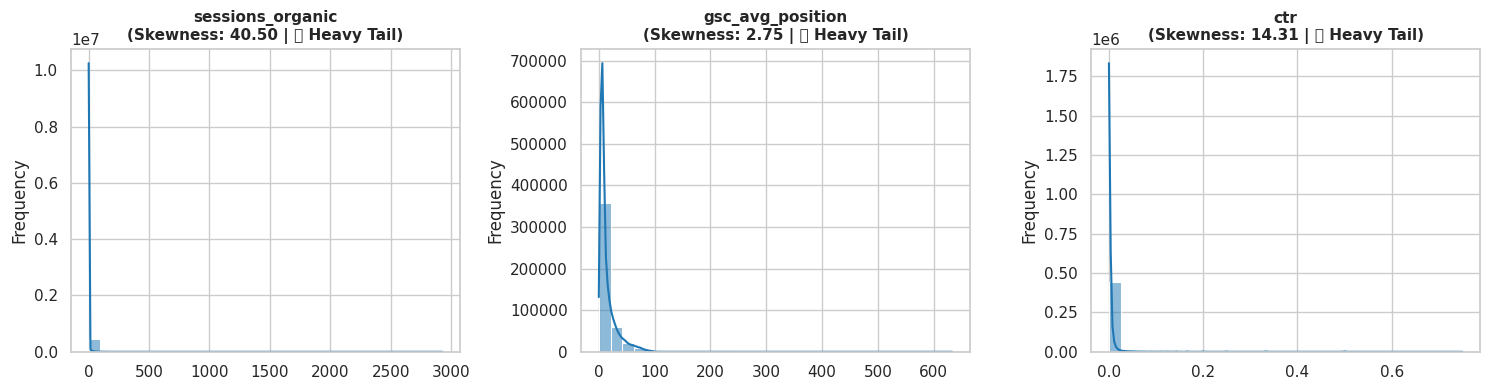

📌 STEP 1: HEAVY TAIL & SKEWNESS AUDIT REPORT


,Feature,Min,Median (50%),Max,Skewness,Heavy Tail Status
0,sessions_organic,0.0,0.00,2925.00,40.504842,Heavy Tail Present (Skewed)
1,gsc_avg_position,0.0,8.37,633.00,2.748763,Heavy Tail Present (Skewed)
2,ctr,0.0,0.00,0.75,14.314926,Heavy Tail Present (Skewed)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

# 1. Load the Parquet Dataset
df = pd.read_parquet('df_featured_cleaned.parquet')

# 2. Select Key Numerical Fields for Distribution Audit
# Baseline numeric fields and key engineered ratios
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Priority features to inspect
key_fields = [col for col in ['clicks', 'impressions', 'sessions_organic',
                              'gsc_avg_position', 'ctr', 'decay_flag'] if col in numeric_cols]

# Fallback if specific names differ: pick top 6 numeric columns
if not key_fields:
    key_fields = numeric_cols[:6]

print(f"📊 Auditing Distributions for Key Fields: {key_fields}\n")

# 3. Create Distribution Plots (Histograms + KDEs)
n_cols = 3
n_rows = (len(key_fields) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(key_fields):
    ax = axes[i]
    # Histogram with KDE curve
    sns.histplot(df[col], kde=True, bins=30, color='#1f77b4', ax=ax)

    # Calculate Skewness
    skew_val = df[col].skew()

    # Dynamic Styling based on Heavy Tail presence
    tail_label = "🔴 Heavy Tail" if abs(skew_val) > 1.0 else "🟢 Balanced"
    ax.set_title(f"{col}\n(Skewness: {skew_val:.2f} | {tail_label})", fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 4. Heavy Tail Quantitative Audit Report
print("="*60)
print("📌 STEP 1: HEAVY TAIL & SKEWNESS AUDIT REPORT")
print("="*60)

audit_df = pd.DataFrame({
    'Feature': key_fields,
    'Min': df[key_fields].min(),
    'Median (50%)': df[key_fields].median(),
    'Max': df[key_fields].max(),
    'Skewness': df[key_fields].skew(),
    'Heavy Tail Status': ['Heavy Tail Present (Skewed)' if abs(s) > 1.0 else 'Normal/Balanced' for s in df[key_fields].skew()]
}).reset_index(drop=True)

display(audit_df)

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.